## II. Principaux frameworks et librairies

Le développement rapide des technologies quantiques s’est accompagné d’une diversification notable des outils logiciels permettant de concevoir, simuler et exécuter des algorithmes quantiques. À mesure que le matériel progresse, les frameworks logiciels jouent un rôle central dans l’exploration des paradigmes de calcul quantique, tant du point de vue théorique qu’applicatif. Ils constituent l’interface essentielle entre les modèles abstraits du calcul quantique et les contraintes concrètes des dispositifs expérimentaux.

Dans ce contexte, il n’existe pas de framework unique répondant de manière optimale à l’ensemble des besoins. Les outils disponibles diffèrent profondément par leur niveau d’abstraction, leur philosophie de conception, les modèles de calcul qu’ils privilégient (circuits quantiques, annealing, approches variationnelles, simulation physique) ainsi que par leurs domaines d’application ciblés. Certains mettent l’accent sur la description fine des circuits et leur compilation vers du matériel réel, d’autres privilégient une approche mathématique rigoureuse fondée sur les équations de la mécanique quantique, tandis que d’autres encore s’inscrivent dans une logique hybride, à l’interface entre calcul quantique et apprentissage automatique.

L’objectif de cette partie est de proposer une présentation structurée et comparative de plusieurs frameworks représentatifs de ces différentes approches. Le choix des outils étudiés reflète à la fois leur adoption dans la communauté académique et industrielle et la diversité des paradigmes qu’ils incarnent. Nous commencerons par présenter OpenQASM, en tant que langage de description de bas niveau des circuits quantiques, avant d’aborder Qiskit et Cirq, deux frameworks majeurs orientés vers le calcul quantique universel sur dispositifs NISQ. Il se poursuit avec QuTiP, qui adopte une perspective résolument ancrée dans la modélisation mathématique et la physique quantique, puis avec l’écosystème D-Wave, centré sur le recuit quantique et la résolution de problèmes d’optimisation. Enfin, PennyLane est présenté comme un framework emblématique des approches hybrides combinant calcul quantique et machine learning.

Dans cette partie, nous essaierons donc de clarifier les positionnements respectifs de ces frameworks, de mettre en évidence leurs forces et leurs limites, et de fournir des éléments d’analyse permettant de choisir l’outil le plus pertinent en fonction des objectifs de recherche ou des contraintes applicatives considérées.

### II.A. Vocabulaire utile pour la compréhension des outils :
* **SDK** : Software Development Kit
* **Transpiler / compiler** : transforme un circuit logique en une suite d’instructions adaptées au matériel physique (mapping, placement, remplacement par portes natives).
* **hybride quantum-classique** : boucle d’optimisation où une machine classique ajuste des paramètres d’un circuit quantique.
* **NISQ** : « Noisy Intermediate-Scale Quantum », appareils actuels (≈ dizaines-centaines de qubits, bruit conséquent).
* **VQE / VQA** : Variational Quantum Eigensolver/Algorithms, algorithme hybride pour trouver l'état fondamental d'un système physique donné, soit pour trouver une approximation de la solution à un problème. Compte tenu d'un guess (ansatz), le processeur quantique calcule l'espérance du système par rapport à un observable (souvent hamiltonien) ; un optimiseur classique est utilisé pour améliorer la supposition.
* **QAOA** : Quantum Approximate Optimization Algorithm, algorithme quantique qui produit des solutions approximatives à des problèmes d'optimisation combinatoire. L'algorithme dépend d'un entier positif p et la qualité de l'approximation s'améliore au fur et à mesure que p augmente. 
* **QPU** : Quantum Processing Unit
* **pulse-level / contrôle bas-niveau** : décrire les signaux RF (Radiofréquence) envoyés au QPU (contrôle précis, calibrage).
* **QCS** : Quantum Contextual Superposition, pas un ensemble d’états définis mais une superposition continue


### II.B. OpenQASM : un langage de description des circuits quantiques

In [14]:
from qiskit import qasm2

OpenQASM (Open Quantum Assembly Language) est un langage de description de bas niveau conçu pour représenter explicitement des circuits quantiques. Initialement développé par IBM, il s’est imposé comme un standard largement utilisé pour l’échange et la sérialisation de circuits entre différents frameworks et backends matériels. OpenQASM ne vise pas à fournir des abstractions algorithmiques, mais à offrir une représentation formelle, lisible et portable des opérations quantiques élémentaires.
Contrairement aux frameworks de haut niveau, OpenQASM n’a pas vocation à fournir des abstractions algorithmiques ou des bibliothèques d’algorithmes. Son objectif principal est de proposer une représentation textuelle formelle et relativement proche du matériel, permettant de décrire précisément l’enchaînement des portes quantiques, les opérations de mesure et les interactions avec des registres classiques.

Le principal avantage d’OpenQASM réside dans sa portabilité et son rôle d’interface commune entre outils logiciels. Il constitue une représentation intermédiaire efficace pour les chaînes de compilation et de transpilation, facilitant l’adaptation des circuits aux contraintes spécifiques des architectures matérielles. En revanche, son niveau d’abstraction limité rend son utilisation directe peu adaptée au développement d’algorithmes complexes, l’écriture manuelle de circuits devenant rapidement peu maintenable.

Dans l’écosystème du calcul quantique, OpenQASM doit ainsi être compris comme une brique fondamentale d’infrastructure logicielle plutôt que comme un framework de développement à part entière. Il joue un rôle clé dans l’interopérabilité entre frameworks et dans la standardisation des descriptions de circuits, tout en laissant aux outils de plus haut niveau la responsabilité de la conception algorithmique.

#### II.B.1) Présentation d’un programme OpenQASM

Un programme OpenQASM simple peut s'écrire sous la forme d'une chaîne de caractères :

In [ ]:
program = """
    OPENQASM 2.0;           
    include "qelib1.inc";  
    qreg q[2];              
    creg c[2];              
 
    h q[0];                 
    cx q[0], q[1];          
 
    measure q -> c;         
"""

# OPENQASM 2.0;            Spécifie la version d'OpenQASM utilisée
# include "qelib1.inc";    Inclut les définitions des portes quantiques standard
# qreg q[2];               Definit un registre quantique à 2 qubits
# creg c[2];               Definit un registre classique à 2 bits pour stocker les résultats de la mesure

Pour obtenir le circuit correspondant, on utilise l'instruction :

```qiskit.qasm2.loads(program, include_path=('.',), custom_instructions=(), custom_classical=(), strict=False)```

qui pour la plupart des programmes peut n'avoir comme paramètre que le programme que l'on souhaite éxecuter :

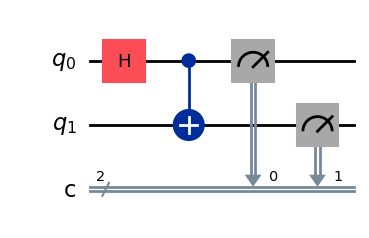

In [16]:
circuit = qasm2.loads(program)
circuit.draw('mpl')

Il existe également l'instruction :

```qiskit.qasm2.load(filename, include_path=('.',), include_input_directory='append', custom_instructions=(), custom_classical=(), strict=False)```

qui permet d'ouvrir un fichier .qasm directement.

In [ ]:
circuit = qasm2.load("myfile.qasm")

Le SDK Qiskit fournit également des outils de conversion entre les représentations OpenQASM des programmes quantiques et la classe QuantumCircuit.

Pour convertir un QuantumCircuit en programme OpenQASM, il suffit donc d'utiliser l'instruction :

```qiskit.qasm2.dump(circuit, filename_or_stream, /)```

In [18]:
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0, 1)
qc.measure(range(2), range(2))

dumped = qasm2.dumps(qc)
 
print(dumped)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


Remarque : filename_or_stream permet d'écrire le programme directement dans un fichier ou un flux en mode texte déjà ouvert.

Ainsi, on peut une nouvelle fois charger la représentation du QuantumCircuit à l'aide de l'instruction .`loads()` :

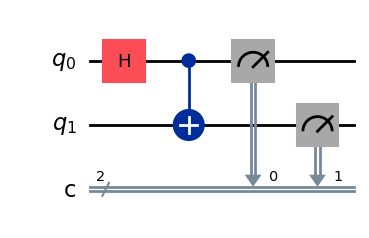

In [19]:
circuit = qasm2.loads(dumped)
circuit.draw('mpl')

#### II.B.2) Personnaliser les instructions

Le package "qelib1.inc" ne contient pas toutes les portes quantiques qu'un utilisateur pourrait vouloir représenter.

OpenQASM 2 permet donc également d'étendre l'ensemble des composants quantiques représentables à l'aide de l'instruction :

```qiskit.qasm2.CustomInstruction(name, num_params, num_qubits, constructor, builtin=False)```

Par exemple, les portes ECR et RZX ne sont pas directement inclues dans le package "qelib1.inc". 

Pour les représenter, il faut donc utiliser les fonctions de Qiskit ECRGate et RZXGate.

*Attention, les paramètres de CustomInstruction doivent correspondre exactement à la déclaration faite dans le QuantumCircuit.*

In [ ]:
from qiskit.circuit.library import ECRGate, RZXGate
 
qc = QuantumCircuit(2)
qc.ecr(0, 1)
qc.rzx(0.3, 0, 1)
qc.rzx(0.7, 1, 0)
qc.rzx(1.5, 0, 1)
qc.ecr(1, 0)
 
dumped = qasm2.dumps(qc)
 
custom = [
    qasm2.CustomInstruction("ecr", 0, 2, ECRGate),
    qasm2.CustomInstruction("rzx", 1, 2, RZXGate),
]
 
loaded = qasm2.loads(dumped, custom_instructions=custom)

Dès lors que nous avons présenté le langage qui permet la représentation formelle des circuits de façon portable, nous allons pouvoir nous intéresser aux principaux frameworks de développement pour la simulation et l'exécution de programmes quantiques.

### II.C. Frameworks Quantiques

#### II.C.1) Qiskit : un framework quantique polyvalent

Qiskit est un framework open source développé initialement par IBM dans le but de fournir un environnement complet pour la programmation, la simulation et l’exécution d’algorithmes quantiques. Il se distingue par son positionnement généraliste et par la richesse de son écosystème, qui en fait aujourd’hui l’un des outils les plus utilisés dans la communauté académique et industrielle. Qiskit vise à couvrir l’ensemble de la chaîne de développement, depuis la conception abstraite des circuits jusqu’à leur exécution sur des dispositifs quantiques réels.

L’architecture de Qiskit est organisée autour de plusieurs modules complémentaires. 
Qiskit Terra constitue le cœur du framework et fournit les outils de création, de manipulation et de transpilation des circuits quantiques. 
Qiskit Aer propose des simulateurs performants, permettant d’expérimenter des algorithmes dans différents modèles de bruit. 
Qiskit Runtime permet l’accès direct à des processeurs quantiques réels, ce qui facilite les expérimentations sur matériel NISQ.

Qiskit offre un niveau d’abstraction intermédiaire, combinant une représentation explicite des circuits quantiques avec des outils de plus haut niveau pour l’implémentation d’algorithmes standard. Il inclut des implémentations de nombreux algorithmes de référence, en particulier des algorithmes variationnels tels que VQE ou QAOA. Le framework met également un accent important sur les étapes de transpilation et d’optimisation, afin d’adapter les circuits aux contraintes topologiques et opérationnelles du matériel cible.

La principale force de Qiskit réside dans sa polyvalence et dans la maturité de son écosystème, soutenu par une documentation abondante et une communauté active. En contrepartie, son intégration étroite avec l’infrastructure IBM peut orienter certains choix de conception et limiter, dans une certaine mesure, son agnosticisme matériel. Malgré cela, Qiskit s’impose comme un outil de référence pour le prototypage, l’enseignement et la recherche en calcul quantique.

Docs : https://quantum.cloud.ibm.com/docs/guides


#### II.C.2) Cirq : un framework orienté NISQ

Cirq est un framework open source développé par Google Quantum AI, conçu spécifiquement pour la programmation de circuits quantiques sur des dispositifs NISQ. Contrairement à des frameworks plus généralistes, Cirq adopte une approche volontairement proche du matériel, avec l’objectif de modéliser de manière fidèle les contraintes physiques et opérationnelles des processeurs quantiques actuels.

L’un des principes structurants de Cirq est la représentation explicite des qubits comme des entités physiques, souvent associées à une géométrie ou à une topologie donnée. Les circuits sont décrits comme des séquences de « moments », chacun regroupant des opérations pouvant être exécutées en parallèle. Cette organisation permet de raisonner naturellement en termes de scheduling, de synchronisation et de contraintes temporelles.

Cirq met également l’accent sur l’utilisation de portes paramétrées et sur la manipulation fine des circuits, ce qui le rend particulièrement adapté aux algorithmes variationnels et aux expériences de calibration. Le framework fournit des outils pour intégrer explicitement le bruit, simuler des comportements réalistes et compiler les circuits en tenant compte des capacités exactes du matériel cible.

En comparaison avec Qiskit, Cirq propose un niveau d’abstraction plus bas et laisse davantage de responsabilités à l’utilisateur, notamment en ce qui concerne l’optimisation et l’adaptation des circuits. Cette approche le rend moins accessible pour un usage généraliste, mais particulièrement pertinent pour des travaux de recherche focalisés sur les architectures NISQ, le contrôle quantique et l’expérimentation proche du matériel.

Docs : https://quantumai.google/cirq


#### II.C.3) QuTiP : une approche mathématique et physique

QuTiP (Quantum Toolbox in Python) est une bibliothèque open source développée principalement pour la simulation et l’analyse de systèmes quantiques à partir des formalismes de la physique quantique. Contrairement aux frameworks orientés calcul quantique universel et programmation par circuits, QuTiP adopte une approche fondamentalement mathématique, centrée sur la manipulation d’états quantiques, d’opérateurs et sur l’étude de leur évolution dynamique.

Le cœur de QuTiP repose sur la représentation explicite des états dans des espaces de Hilbert, sous forme de vecteurs d’état ou de matrices densité, ainsi que sur la définition d’opérateurs linéaires agissant sur ces espaces. Le framework fournit des outils pour modéliser l’évolution temporelle des systèmes quantiques fermés et ouverts, notamment via l’équation de Schrödinger et les équations maîtres de type Lindblad. Cette approche permet d’intégrer naturellement les effets de dissipation, de décohérence et d’interactions avec l’environnement.

QuTiP est particulièrement adapté à l’étude de systèmes continus ou de petite dimension, typiquement rencontrés en optique quantique, en information quantique théorique ou en physique des systèmes ouverts. Il permet d’extraire des observables physiques, d’analyser des dynamiques transitoires et d’explorer des régimes difficilement accessibles par une description purement discrète en termes de circuits.

En ce sens, QuTiP se distingue clairement des frameworks comme Qiskit ou Cirq. Il ne vise ni l’exécution sur matériel quantique réel ni la compilation de circuits, mais constitue un outil privilégié pour la modélisation, la simulation et la compréhension fine de phénomènes quantiques. Il s’adresse principalement à des usages académiques où la rigueur mathématique et la fidélité au modèle physique priment sur la programmation algorithmique.

Docs : https://qutip.org/


#### II.C.4) D-Wave : le calcul quantique par recuit

D-Wave se distingue des frameworks précédemment présentés par son modèle de calcul, fondé non pas sur le calcul quantique universel à base de portes, mais sur le recuit quantique (quantum annealing). Cette approche vise à résoudre des problèmes d’optimisation combinatoire en exploitant l’évolution adiabatique d’un système quantique vers un état d’énergie minimale. Concrètement, de la même manière qu’un recuit classique utilise la chaleur et les fluctuations thermiques, le recuit quantique utilise des fluctuations quantiques (effet tunnel, superposition) pour franchir les barrières d’énergie et éviter de rester bloqué dans des minima locaux. Cette approche s’inscrit donc dans un cadre conceptuel et algorithmique bien différent de celui des circuits quantiques standards.

Le formalisme mathématique sous-jacent repose sur la formulation des problèmes sous forme de modèles d’Ising ou de problèmes QUBO (Quadratic Unconstrained Binary Optimization). L’enjeu principal n’est pas la conception de circuits, mais la traduction d’un problème applicatif en une fonction de coût quadratique, intégrant éventuellement des contraintes via des termes de pénalisation. Cette étape de modélisation est centrale et conditionne fortement la qualité des résultats obtenus.

D-Wave propose un écosystème logiciel, principalement à travers le SDK Ocean, qui fournit des outils pour définir, transformer et résoudre des problèmes d’optimisation sur ses machines. L’intégration avec Python facilite l’usage du matériel D-Wave dans des chaînes de calcul hybrides, combinant pré- et post-traitements classiques avec l’exécution quantique. Des solveurs classiques et quantiques sont souvent utilisés conjointement afin de pallier les limitations matérielles.

Bien que les performances et l’avantage quantique du recuit quantique fassent l’objet de débats, l’approche D-Wave a démontré une utilité pratique pour certaines classes de problèmes, notamment en optimisation, en planification et en analyse de graphes. Il est toutefois important de souligner que cette technologie ne permet pas l’implémentation d’algorithmes quantiques universels et doit être considérée comme une solution spécialisée, complémentaire aux frameworks orientés circuits.

Docs : https://docs.dwavequantum.com/en/latest/ocean/


#### II.C.5) PennyLane : le calcul quantique pour le ML

PennyLane est un framework open source développé par Xanadu, conçu spécifiquement pour l’exploration des approches hybrides combinant calcul quantique et apprentissage automatique. Il s’inscrit dans le cadre des algorithmes variationnels, où des circuits quantiques paramétrés sont intégrés au sein de boucles d’optimisation classiques, selon un paradigme proche de celui du machine learning moderne.

Le concept central de PennyLane est celui de circuit quantique différentiable. Le framework permet de définir des circuits paramétrés dont les sorties peuvent être différenciées par rapport aux paramètres, en s’appuyant sur des règles analytiques propres au calcul quantique. Cette différentiabilité rend possible l’utilisation directe d’algorithmes d’optimisation issus du machine learning, tels que la descente de gradient, et facilite l’intégration avec des bibliothèques classiques comme PyTorch, TensorFlow ou JAX.

PennyLane se distingue également par son agnosticisme matériel. Il peut s’appuyer sur de nombreux backends, incluant des simulateurs classiques et des dispositifs quantiques réels via des interfaces avec Qiskit, Cirq ou d’autres plateformes. Cette flexibilité permet de prototyper des modèles hybrides sans dépendre d’une architecture spécifique, tout en conservant la possibilité de déployer les circuits sur du matériel réel.

En pratique, PennyLane est principalement utilisé pour des applications de type quantum machine learning, telles que les réseaux de neurones quantiques, les classificateurs variationnels ou les méthodes à noyaux quantiques. Si ces approches restent largement exploratoires et soumises aux limitations du régime NISQ, PennyLane fournit un cadre conceptuel et logiciel cohérent pour étudier l’intersection entre apprentissage automatique et calcul quantique, en mettant l’accent sur l’expérimentation et la recherche méthodologique.

Docs : https://docs.pennylane.ai/


#### II.C.6) Conclusion : Comparaison transversale des frameworks

Les frameworks étudiés illustrent la diversité des paradigmes du calcul quantique actuel. Qiskit et Cirq relèvent du calcul quantique universel basé sur les circuits, tandis que D-Wave s’appuie sur le recuit quantique pour la résolution de problèmes d’optimisation. QuTiP adopte une approche de simulation ancrée dans les formalismes de la physique quantique, et PennyLane se situe à l’interface entre calcul quantique et apprentissage automatique à travers des modèles hybrides variationnels.

Ils se distinguent également par leur niveau d’abstraction. Qiskit propose un cadre polyvalent combinant expressivité algorithmique et accès au matériel. Cirq privilégie une modélisation bas niveau, fidèle aux contraintes des dispositifs NISQ. OpenQASM joue un rôle transversal de langage intermédiaire pour la description et la compilation des circuits. À l’opposé, PennyLane offre une abstraction élevée orientée machine learning, tandis que QuTiP se concentre sur la manipulation directe d’objets mathématiques et physiques.

Ces différences se reflètent dans les cas d’usage privilégiés : Qiskit et Cirq pour le prototypage et l’expérimentation d’algorithmes sur matériel réel, QuTiP pour la recherche théorique et la simulation de systèmes quantiques, D-Wave pour l’optimisation combinatoire, et PennyLane pour l’exploration des approches de quantum machine learning. Aucun framework ne s’impose comme universel ; le choix de l’outil dépend avant tout du modèle de calcul adopté et des objectifs scientifiques ou applicatifs visés.

Cette première partie a mis en évidence la diversité des frameworks de calcul quantique et des paradigmes qu’ils incarnent. Derrière cette pluralité d’outils se trouvent toutefois des concepts communs, qui constituent le socle théorique sur lequel reposent la plupart des approches présentées, en particulier celles fondées sur le modèle par circuits.

La seconde partie du rapport vise donc à revenir à ces fondamentaux de l’informatique quantique. Elle introduit d’abord le paradigme du calcul quantique à travers la représentation des états par des vecteurs et l’action des portes quantiques, éléments centraux de la programmation quantique. Ces notions sont ensuite mises en pratique à travers l’étude d’un programme quantique simple mais emblématique : l’algorithme de Grover, qui illustre concrètement la manière dont ces principes se traduisent en gain algorithmique. Par la suite nous verrons un exemple plus complexe: le problème du voyageur de commerce.